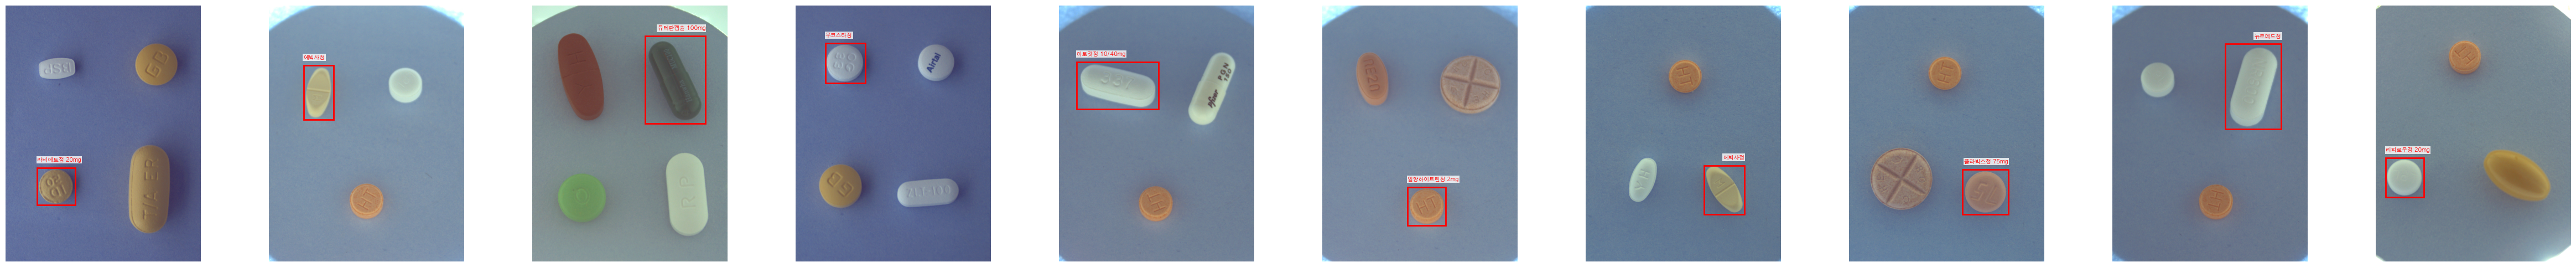

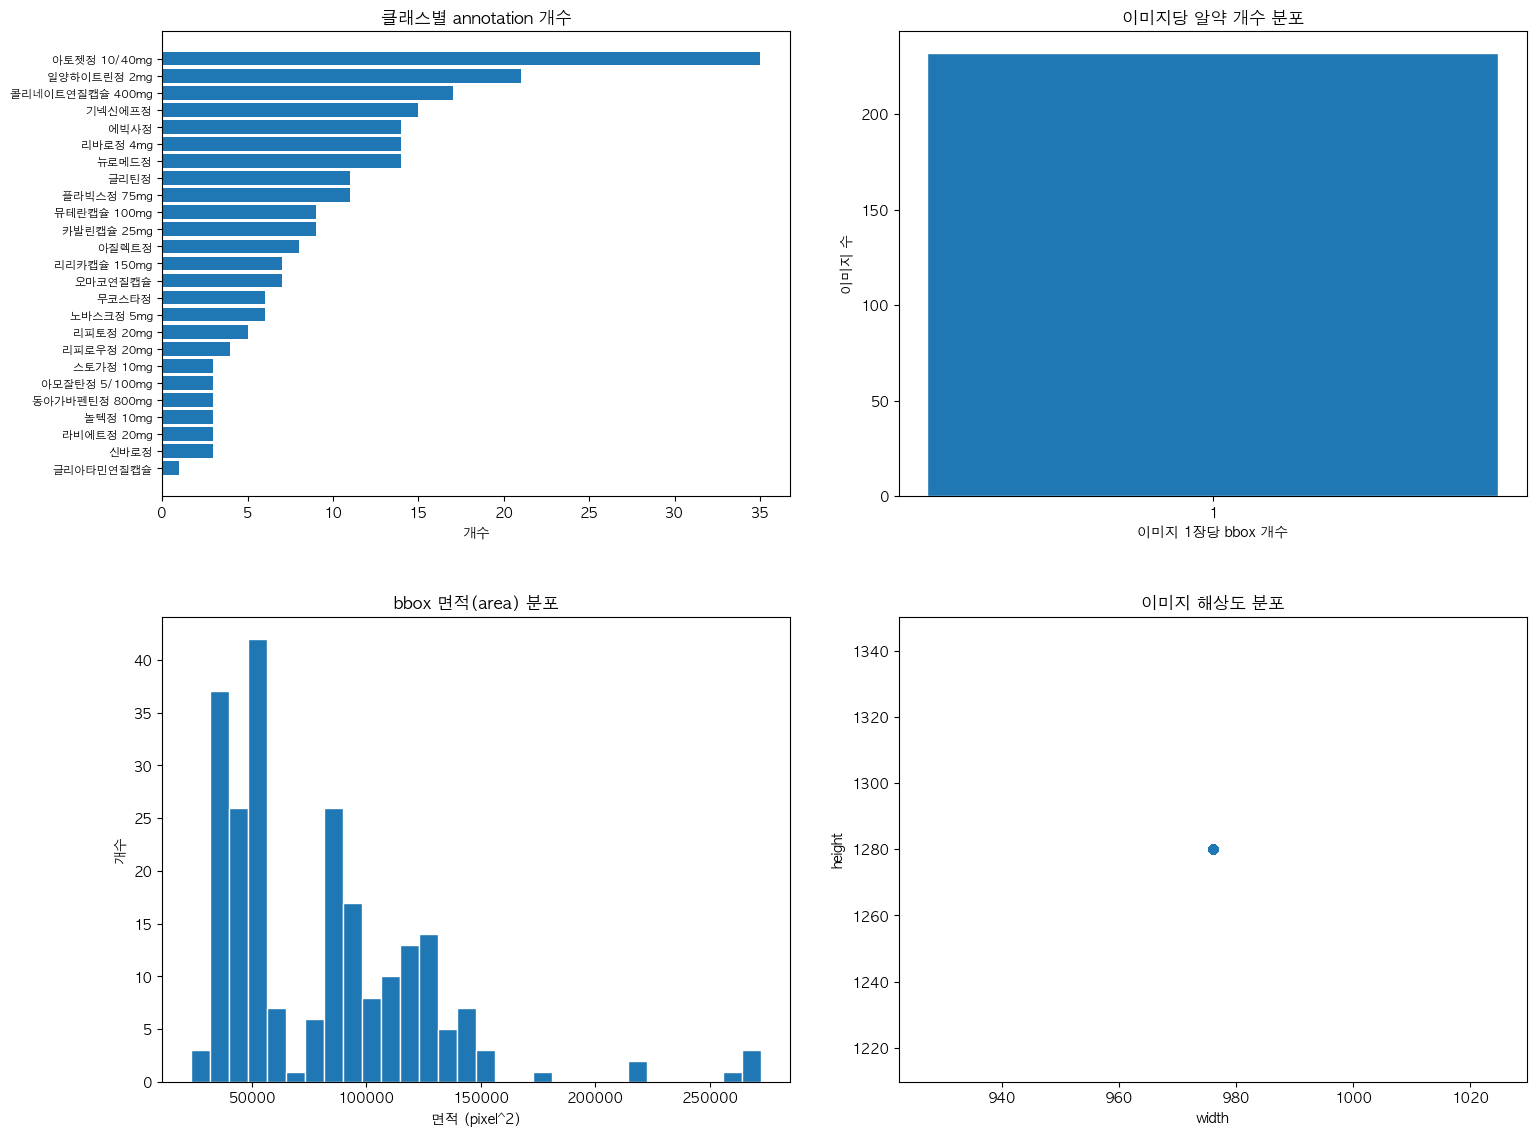

===== EDA 요약 =====
총 이미지 수: 232
총 클래스 수: 25
클래스별 최소/최대 개수: 1 / 35
이미지당 평균 bbox 개수: 1.00
bbox 면적 평균/최소/최대: 79701 / 23250 / 272435
이미지 해상도 종류 수: 1


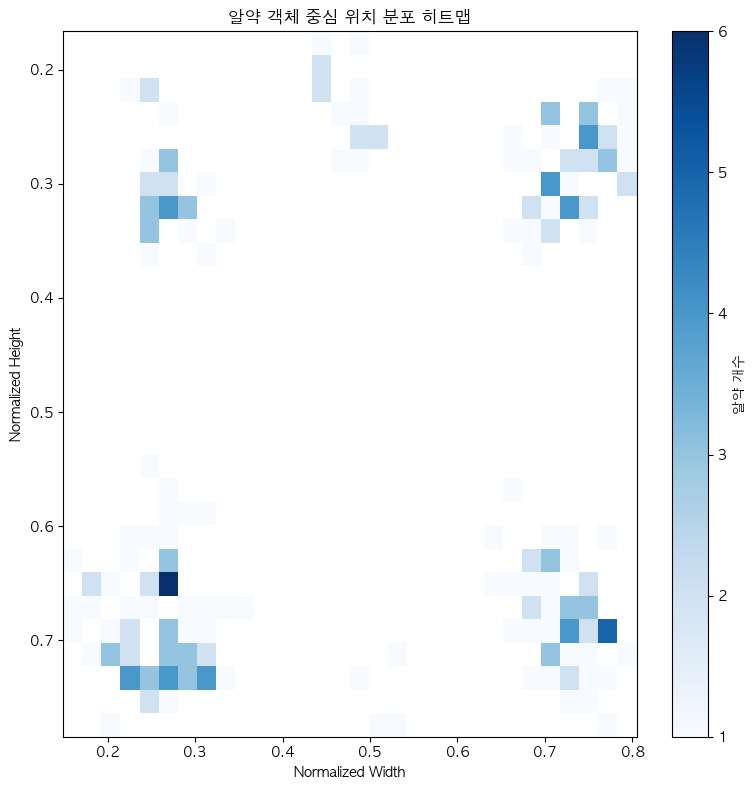

===== 객체 위치 분포 분석 완료 =====
분석된 객체 중심점 수: 232개


In [3]:
import os
import random
import json
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sys.path.append('../src')
from dataset import PillDataset, get_train_paths

# 한글 폰트 설정 (맥 기본 내장 폰트)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False


def visualize_samples(dataset, num_samples=4):
    #샘플 이미지와 어노테이션(박스, 이름) 시각화
    indices = random.sample(range(len(dataset)), num_samples)
    fig, axes = plt.subplots(1, num_samples, figsize=(6 * num_samples, 6))

    for ax, idx in zip(axes, indices):
        image, target = dataset[idx]
        ax.imshow(image)
        img_width, img_height = image.size

        boxes = target["boxes"]
        labels = target["labels"]

        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box.tolist()
            w, h = x2 - x1, y2 - y1
            rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

            full_name = dataset.label_to_name[label.item()]
            short_name = full_name.split('(')[0].strip()

            if x1 > img_width / 2:
                text_x, ha = x2, 'right'
            else:
                text_x, ha = x1, 'left'

            offset = 25
            if y1 - offset > 0:
                text_y, va = y1 - offset, 'bottom'
            else:
               text_y, va = y2 + offset, 'top'

            ax.text(
                text_x, text_y, short_name,
                color='red', fontsize=7,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1),
                clip_on=True, ha=ha, va=va,
            )

        ax.axis('off')

    plt.subplots_adjust(wspace=0.3)
    plt.show()


def run_eda(dataset):
    # 클래스 분포, bbox 개수/크기, 이미지 해상도 확인하는 EDA

    class_counts = {}
    bbox_counts_per_image = []
    bbox_areas = []
    img_widths = []
    img_heights = []

    for idx in range(len(dataset)):
        img_path = dataset.img_paths[idx]
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        json_path = dataset.ann_map.get(base_name)

        if json_path is None:
            continue

        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        for img_info in data.get('images', []):
            img_widths.append(img_info['width'])
            img_heights.append(img_info['height'])

        anns = data.get('annotations', [])
        bbox_counts_per_image.append(len(anns))

        for ann in anns:
            x, y, w, h = ann['bbox']
            bbox_areas.append(w * h)

            cat_id = ann['category_id']
            label = dataset.category_id_to_label[cat_id]
            full_name = dataset.label_to_name[label]
            short_name = full_name.split('(')[0].strip()
            class_counts[short_name] = class_counts.get(short_name, 0) + 1

    sorted_items = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    names = [item[0] for item in sorted_items]
    counts = [item[1] for item in sorted_items]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 클래스별 개수
    axes[0, 0].barh(range(len(names)), counts)
    axes[0, 0].set_yticks(range(len(names)))
    axes[0, 0].set_yticklabels(names, fontsize=8)
    axes[0, 0].invert_yaxis()
    axes[0, 0].set_title("클래스별 annotation 개수")
    axes[0, 0].set_xlabel("개수")

    # 이미지당 알약 개수 분포
    max_count = max(bbox_counts_per_image)
    bins = [x - 0.5 for x in range(1, max_count + 2)]
    axes[0, 1].hist(bbox_counts_per_image, bins=bins, edgecolor='white')
    axes[0, 1].set_xticks(range(1, max_count + 1))
    axes[0, 1].set_title("이미지당 알약 개수 분포")
    axes[0, 1].set_xlabel("이미지 1장당 bbox 개수")
    axes[0, 1].set_ylabel("이미지 수")

    # bbox 면적 분포
    axes[1, 0].hist(bbox_areas, bins=30, edgecolor='white')
    axes[1, 0].set_title("bbox 면적(area) 분포")
    axes[1, 0].set_xlabel("면적 (pixel^2)")
    axes[1, 0].set_ylabel("개수")

    # 이미지 해상도 분포
    axes[1, 1].scatter(img_widths, img_heights, alpha=0.5)
    axes[1, 1].set_title("이미지 해상도 분포")
    axes[1, 1].set_xlabel("width")
    axes[1, 1].set_ylabel("height")

    plt.tight_layout(pad=3.0, h_pad=4.0)
    plt.show()

    print("===== EDA 요약 =====")
    print(f"총 이미지 수: {len(dataset)}")
    print(f"총 클래스 수: {len(class_counts)}")
    print(f"클래스별 최소/최대 개수: {min(counts)} / {max(counts)}")
    print(f"이미지당 평균 bbox 개수: {sum(bbox_counts_per_image)/len(bbox_counts_per_image):.2f}")
    print(f"bbox 면적 평균/최소/최대: {sum(bbox_areas)/len(bbox_areas):.0f} / {min(bbox_areas)} / {max(bbox_areas)}")
    print(f"이미지 해상도 종류 수: {len(set(zip(img_widths, img_heights)))}")


# 알약 객체 중심 위치 분포 히트맵 (0~1 정규화 좌표 기준)
def plot_object_heatmap(dataset):
    # 이미지 내 알약 객체들의 위치 집중도(밀도) 히트맵 탐색
    center_x_list = []
    center_y_list = []
        
    for idx in range(len(dataset)):
        img_path = dataset.img_paths[idx]
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        json_path = dataset.ann_map.get(base_name)
            
        if json_path is None:
            continue
                
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
                
        img_info = data.get('images', [{}])[0]
        img_w = img_info.get('width', 1)
        img_h = img_info.get('height', 1)
            
        for ann in data.get('annotations', []):
            x, y, w, h = ann['bbox']
            cx = (x + w / 2) / img_w
            cy = (y + h / 2) / img_h
                
            center_x_list.append(cx)
            center_y_list.append(cy)
                
    plt.figure(figsize=(8, 8))
    plt.hist2d(center_x_list, center_y_list, bins=30, cmap='Blues', cmin=1)
    plt.colorbar(label='알약 개수')
    plt.title("알약 객체 중심 위치 분포 히트맵")
    plt.xlabel("Normalized Width")
    plt.ylabel("Normalized Height")
        
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
        
    print("===== 객체 위치 분포 분석 완료 =====")
    print(f"분석된 객체 중심점 수: {len(center_x_list)}개")


img_dir, ann_dir = get_train_paths()
dataset = PillDataset(img_dir=img_dir, ann_dir=ann_dir, transform=None)

# 샘플 이미지 및 바운딩 박스 시각화
visualize_samples(dataset, num_samples=10)

# 클래스 분포, bbox 통계, 해상도 분포 통계 탐색
run_eda(dataset)

# 객체 위치 밀도 히트맵 탐색
plot_object_heatmap(dataset)